#Project Name: Integrated Retail Analytics for Store Optimization and Demand Forecasting

## Project Objectives:
###To utilize machine learning and data analysis techniques to optimize store performance, forecast demand, and enhance customer experience through segmentation and personalized marketing strategies.

##Project Summary:  
#####This project focuses on analyzing retail sales data to improve store performance and forecast future demand. I used three datasets: sales, stores, and features, which were merged to create a unified dataset. Data preprocessing was performed by handling missing values, fixing data types, and creating new time-based features
Anomaly detection was applied using the Z-score method to identify unusual sales patterns. Time-based analysis helped in understanding seasonal trends and sales variations. I performed store segmentation using clustering techniques to group stores based on performance.
Market basket analysis was approximated using department-level sales to identify relationships between product categories. A regression model was built to forecast future sales based on historical trend
External factors like CPI, fuel price, and unemployment were analyzed to understand their impact on sales. Based on the insights, strategies were suggested for inventory management, marketing, and store optimization.

##GIT-HUB LINK:

##Problem Statement:  
#####In the retail industry, businesses often face challenges in understanding sales patterns, managing inventory, and forecasting future demand due to large and complex datasets. The lack of insights into anomalies, seasonal trends, and the impact of external factors like economic conditions can lead to poor decision-making and reduced profitability.

This project aims to analyze retail sales data by integrating multiple datasets to identify unusual sales patterns, understand time-based trends, and segment stores based on performance. It also focuses on building predictive models for demand forecasting and analyzing the influence of external factors such as CPI, fuel prices, and unemployment.  
The ultimate goal is to provide data-driven insights and actionable strategies to optimize store operations, improve inventory management, and enhance overall business performance

#Let's Begin:

##Import Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

####I imported necessary libraries such as Pandas and NumPy for data processing, Matplotlib and Seaborn for visualization, and Scikit-learn for clustering, regression, and model evaluation.

##Load Datasets:

In [2]:
sales = pd.read_csv("sales data-set.csv")
stores = pd.read_csv("stores data-set.csv")
features = pd.read_csv("Features data set.csv")

#####I loaded the three datasets: sales, stores, and features data using Pandas.

##Understand the data:

In [3]:
# view first rows
print(sales.head())
print(stores.head())
print(features.head())


   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
3      1     1  26/02/2010      19403.54      False
4      1     1  05/03/2010      21827.90      False
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  05/02/2010        42.31       2.572        NaN        NaN   
1      1  12/02/2010        38.51       2.548        NaN        NaN   
2      1  19/02/2010        39.93       2.514        NaN        NaN   
3      1  26/02/2010        46.63       2.561        NaN        NaN   
4      1  05/03/2010        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         

In [4]:
# check the structure
sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


####I explored the datasets using head() and info() to understand their structure and data types.

## Merge Datasets:

In [5]:
data = pd.merge(sales, stores, on="Store", how="left")
data = pd.merge(data, features, on=["Store","Date"], how="left")

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,05/02/2010,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,12/02/2010,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,19/02/2010,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,26/02/2010,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,05/03/2010,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


####
I merged the datasets using Store and Date columns and verified the merged data using head() function.”

##Fix Columns:

In [6]:
data["IsHoliday"] = data["IsHoliday_x"]
data.drop(["IsHoliday_x","IsHoliday_y"], axis=1, inplace=True)

data.head()

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,1,05/02/2010,24924.50,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,12/02/2010,46039.49,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,19/02/2010,41595.55,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,26/02/2010,19403.54,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,05/03/2010,21827.90,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


###I handled duplicate columns created after merging

##Data Cleaning:


In [7]:
data["Date"] = pd.to_datetime(data["Date"], format="%d/%m/%Y")

markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
data[markdown_cols] = data[markdown_cols].fillna(0)

data.head()

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False


####I handled missing values in the dataset, especially in markdown features, by replacing null values with zero. This ensures the dataset is complete and suitable for analysis.”

##Feature Engineering:

In [8]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Week"] = data["Date"].dt.isocalendar().week

data.head()

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Week
0,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,2010,2,5
1,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,2010,2,6
2,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,2010,2,7
3,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,2010,2,8
4,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,2010,3,9


####I created time-based features like year, month, and week to capture seasonal patterns in sales.   

Feature engineering helps in creating meaningful variables that improve analysis and model performance.”

In [9]:
data["Total_MarkDown"] = data[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].sum(axis=1)
data.head()

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Week,Total_MarkDown
0,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,2010,2,5,0.0
1,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,2010,2,6,0.0
2,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,2010,2,7,0.0
3,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,2010,2,8,0.0
4,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,2010,3,9,0.0


#####I created a total markdown feature by combining all markdown columns to represent overall promotional activity.

##Anomaly Detection in Sales Data:

In [10]:
#1. Identify Unusual Sales Patterns
mean = data["Weekly_Sales"].mean()
std = data["Weekly_Sales"].std()

data["z_score"] = (data["Weekly_Sales"] - mean) / std

anomalies = data[(data["z_score"] > 3) | (data["z_score"] < -3)]

anomalies.head()

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Week,Total_MarkDown,z_score
618,1,5,2010-12-24,85676.09,A,151315,52.33,2.886,0.00,0.00,...,0.0,0.00,211.405122,7.838,False,2010,12,51,0.00,3.068745
903,1,7,2010-12-17,96198.12,A,151315,49.84,2.869,0.00,0.00,...,0.0,0.00,211.405312,7.838,False,2010,12,50,0.00,3.532042
904,1,7,2010-12-24,166697.72,A,151315,52.33,2.886,0.00,0.00,...,0.0,0.00,211.405122,7.838,False,2010,12,51,0.00,6.636222
956,1,7,2011-12-23,119302.15,A,151315,47.96,3.112,2725.36,40.48,...,24.9,2739.43,219.357722,7.866,False,2011,12,51,6164.87,4.549340
5118,1,38,2010-02-05,115564.35,A,151315,42.31,2.572,0.00,0.00,...,0.0,0.00,211.096358,8.106,False,2010,2,5,0.00,4.384760


####I identified unusual sales patterns using the Z-score method. Values far from the mean were considered anomalies. These represent unexpected spikes or drops in sales across stores and departments.

In [11]:
#2. Investigate Causes of Anomalies
#Check holiday impact
anomalies[["Date","Store","Dept","Weekly_Sales","IsHoliday"]].head()

,Date,Store,Dept,Weekly_Sales,IsHoliday
618,2010-12-24,1,5,85676.09,False
903,2010-12-17,1,7,96198.12,False
904,2010-12-24,1,7,166697.72,False
956,2011-12-23,1,7,119302.15,False
5118,2010-02-05,1,38,115564.35,False


In [12]:
#Check markdowns (discounts)
anomalies[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].head()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
618,0.00,0.00,0.0,0.0,0.00
903,0.00,0.00,0.0,0.0,0.00
904,0.00,0.00,0.0,0.0,0.00
956,2725.36,40.48,634.7,24.9,2739.43
5118,0.00,0.00,0.0,0.0,0.00


####I analyzed anomalies by checking holiday effects, markdowns. I observed that many anomalies occur during promotional periods and holidays.

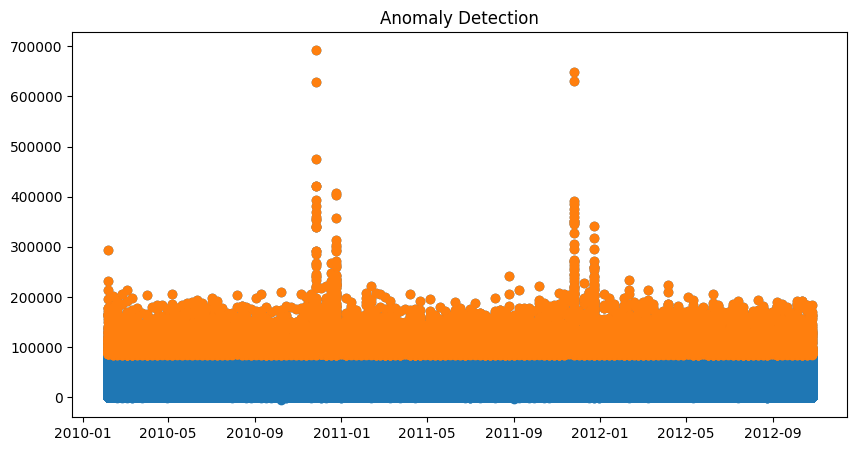

In [13]:
#Visualization
plt.figure(figsize=(10,5))
plt.scatter(data["Date"], data["Weekly_Sales"])
plt.scatter(anomalies["Date"], anomalies["Weekly_Sales"])
plt.title("Anomaly Detection")
plt.show()

####I plotted the weekly sales data to visualize anomalies. Most of the data points are concentrated in a normal range, while a few points show very high spikes. These spikes represent unusual sales patterns, which are identified as anomalies. These may occur due to holidays, promotions, or external factors.  

Blue/Orange dense area - normal sales  
Tall Spikes - anomalies


##Time-Based Anomaly Detection:

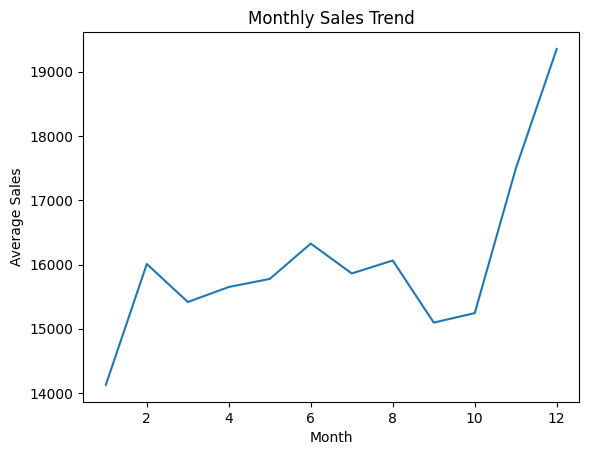

In [14]:
#Sales Trend Over Time
monthly_sales = data.groupby("Month")["Weekly_Sales"].mean()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

####I analyzed sales trends over time by grouping data by month. This helped in understanding how sales vary across different months.

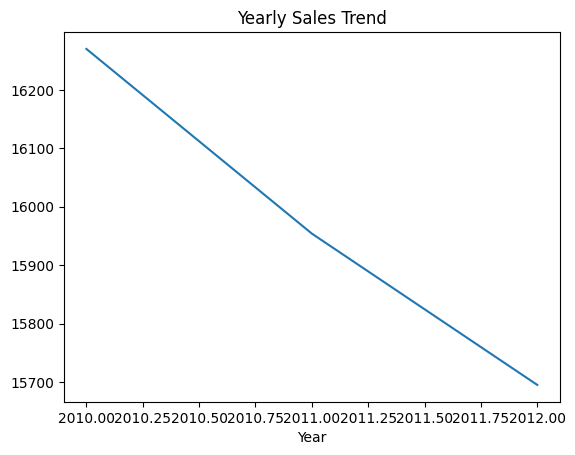

In [15]:
#Yearly Trend
yearly_sales = data.groupby("Year")["Weekly_Sales"].mean()

yearly_sales.plot()
plt.title("Yearly Sales Trend")
plt.show()

####I also analyzed yearly trends to observe overall growth or decline in sales.

In [16]:
#Holiday Effect
holiday_sales = data.groupby("IsHoliday")["Weekly_Sales"].mean()
print(holiday_sales)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


####I analyzed the impact of holidays on sales and found that average sales during holidays are higher compared to non-holiday periods. This indicates that holidays have a positive impact on sales due to increased customer demand and promotional activities.

In [17]:
#Use time-series analysis for understanding store and department performance over time
#Store-wise Trend
store_sales = data.groupby(["Date","Store"])["Weekly_Sales"].sum().reset_index()

store_sales.head()

,Date,Store,Weekly_Sales
0,2010-02-05,1,1643690.90
1,2010-02-05,2,2136989.46
2,2010-02-05,3,461622.22
3,2010-02-05,4,2135143.87
4,2010-02-05,5,317173.10


####I analyzed store-wise sales trends over time to understand how individual stores perform.

In [18]:
#Department-wise Trend
dept_sales = data.groupby(["Date","Dept"])["Weekly_Sales"].sum().reset_index()

dept_sales.head()

,Date,Dept,Weekly_Sales
0,2010-02-05,1,881833.41
1,2010-02-05,2,1997831.89
2,2010-02-05,3,484368.90
3,2010-02-05,4,1205801.77
4,2010-02-05,5,1116952.54


####I analyzed department-wise trends to observe how different departments perform over time.

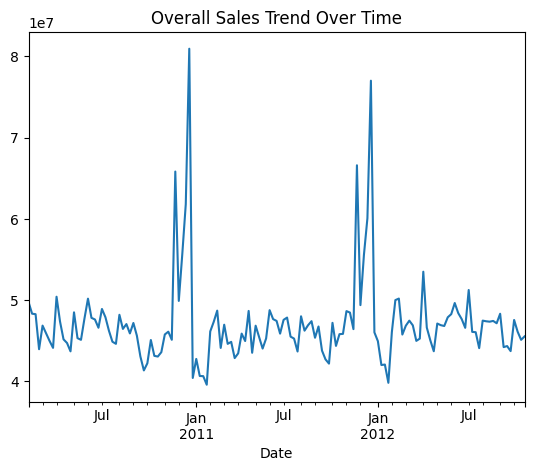

In [19]:
#Overall Time-Series Trend
overall_sales = data.groupby("Date")["Weekly_Sales"].sum()

overall_sales.plot()
plt.title("Overall Sales Trend Over Time")
plt.show()

####I plotted overall sales trends over time to understand general patterns and seasonality.

#####I used time-series analysis to study sales performance over time at both store and department levels. By analyzing trends and patterns, I identified seasonal variations and fluctuations in sales. This helps in understanding how different stores and departments perform and supports better decision-making.

##Customer Segmentation Analysis:

In [20]:
#Select Features
seg_data = data[["Weekly_Sales", "Size", "Total_MarkDown"]].dropna()

seg_data.head()

,Weekly_Sales,Size,Total_MarkDown
0,24924.50,151315,0.0
1,46039.49,151315,0.0
2,41595.55,151315,0.0
3,19403.54,151315,0.0
4,21827.90,151315,0.0


####I selected important features such as weekly sales, store size, and total markdown for segmentation. These features represent store performance and promotional activity. I also removed missing values to ensure clean input for the model.

In [21]:
#Apply K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
seg_data["Cluster"] = kmeans.fit_predict(seg_data)

####I applied K-Means clustering to group stores into three segments. The algorithm assigns each data point to a cluster based on similarity. This helps in identifying different store performance groups.

In [22]:
#Add Cluster Labels to Dataset
data.loc[seg_data.index, "Cluster"] = seg_data["Cluster"]

####I added the cluster labels back to the main dataset so that each store record is associated with a specific segment. This helps in further analysis of each group.

In [23]:
#Analyze Clusters
cluster_summary = data.groupby("Cluster")[["Weekly_Sales","Size","Total_MarkDown"]].mean()
print(cluster_summary)

         Weekly_Sales           Size  Total_MarkDown
Cluster                                             
0.0      22840.292152  203217.881818     9595.640353
1.0       8155.666626   44459.932368     1825.197897
2.0      14151.194776  127597.084738     6713.624019


####I analyzed each cluster by calculating the average sales, store size, and markdown values. This helps in understanding the characteristics of each segment.

In [24]:
#Evaluate Model
sample_data = seg_data.sample(n=5000, random_state=0)

score = silhouette_score(
    sample_data[["Weekly_Sales","Size","Total_MarkDown"]],
    sample_data["Cluster"]
)

print("Silhouette Score:", score)

Silhouette Score: 0.5690323264092436


####I evaluated clustering using silhouette score. Since the dataset is large, I used a sample of data to compute the score efficiently.  
####I obtained a silhouette score of 0.56, which indicates good clustering performance. This shows that the clusters are well separated and the segmentation is meaningful.”

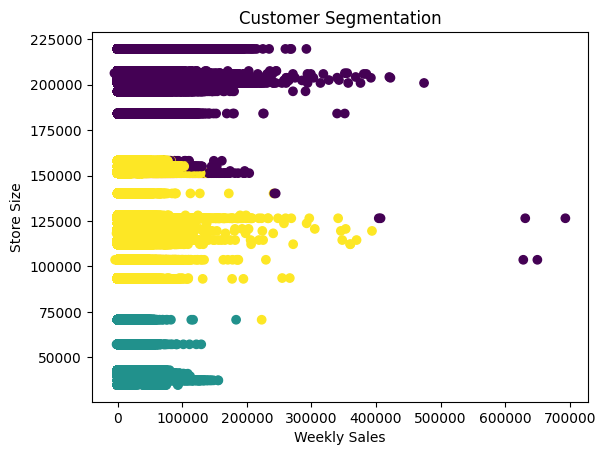

In [25]:
#Visualization
import matplotlib.pyplot as plt

plt.scatter(seg_data["Weekly_Sales"], seg_data["Size"], c=seg_data["Cluster"])
plt.xlabel("Weekly Sales")
plt.ylabel("Store Size")
plt.title("Customer Segmentation")
plt.show()

####I visualized the customer segmentation using a scatter plot, where each color represents a different cluster. The clusters clearly show groups of stores based on their sales and size. I identified high-performing, medium-performing, and low-performing store segments.

###Using clustering, I identified different store segments such as high-performing, medium-performing, and low-performing stores based on sales and other features.

##Market Basket Analysis:

In [26]:
#Find Top Departments
dept_sales = data.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)

print(dept_sales.head(5))

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
Name: Weekly_Sales, dtype: float64


####I analyzed department-level sales and found that departments like 92, 95, and 38 are the top-performing departments with the highest total sales. This indicates that these departments contribute significantly to overall revenue.  
These high-performing departments can be used for cross-selling strategies by promoting related products together.”

In [27]:
#Compare Departments
pivot_table = data.pivot_table(values="Weekly_Sales", index="Date", columns="Dept")

pivot_table.head()

Dept,1,2,3,4,5,6,7,8,9,10,...,90,91,92,93,94,95,96,97,98,99
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-05,19596.298000,44396.264222,10763.753333,26795.594889,24821.167556,4923.649524,16999.288000,33943.070444,12458.780465,17192.953333,...,48869.056000,39018.272000,84025.841556,28420.043902,36149.530833,70456.220667,12637.064375,14910.795455,7149.398780,0.015
2010-02-12,32381.831111,40871.506000,9540.911556,23890.702667,26700.751628,6002.061190,17377.267111,30563.850889,13073.830698,16940.854667,...,45136.825556,35622.515333,76529.717778,26278.602439,29933.405909,66136.651333,14027.032187,13946.563864,8987.685476,0.010
2010-02-19,24850.163556,43593.020667,9119.980889,24750.705333,25243.578864,6160.518810,18737.230222,31429.293556,13354.368636,17339.745333,...,43915.903111,34358.170444,73622.038000,24513.449268,33627.329778,62534.173111,12372.622500,12948.836818,7092.973256,4.495
2010-02-26,15142.035111,41322.924000,9223.560444,23907.430889,19896.952093,5057.153095,15984.829778,30389.714889,13068.847907,17252.708444,...,43002.549556,33027.648667,71204.668000,23172.368293,30305.467500,61986.936222,12476.014063,12424.505455,7185.641892,NaN
2010-03-05,16947.834889,43508.240444,9392.897111,25455.694444,21643.893953,4836.523095,17322.672889,32316.713111,14653.438605,16948.534222,...,44570.462889,35729.234889,77349.449111,25659.619268,34794.528649,66540.872000,12342.925312,13604.273864,7321.817568,0.010


####I created a pivot table to compare sales patterns of different departments over time.

In [28]:
#Correlation Between Departments
dept_corr = pivot_table.corr()
dept_corr.head()


Dept,1,2,3,4,5,6,7,8,9,10,...,90,91,92,93,94,95,96,97,98,99
Dept,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.261559,-0.173061,0.017302,0.511806,0.293486,0.489972,0.513402,-0.046796,0.193405,...,0.404231,0.032967,0.334751,0.123204,-0.113455,-0.233085,-0.072031,-0.094930,0.537791,0.264135
2,0.261559,1.000000,0.424812,0.721706,0.339149,0.417076,0.591915,0.671484,0.557394,0.695223,...,0.503639,0.249068,0.419944,0.469328,0.264987,0.566541,0.407389,0.528037,0.333712,0.389217
3,-0.173061,0.424812,1.000000,0.457733,-0.113336,-0.032677,-0.048925,-0.067416,0.174778,0.163630,...,0.062142,-0.008273,0.015343,0.033453,0.215273,0.285822,0.119783,0.251410,-0.176466,0.022269
4,0.017302,0.721706,0.457733,1.000000,0.265828,0.363966,0.434208,0.475531,0.549153,0.667213,...,0.566248,0.276722,0.537261,0.689191,0.187063,0.571865,0.616125,0.645742,0.162367,0.324178
5,0.511806,0.339149,-0.113336,0.265828,1.000000,0.863479,0.868130,0.551074,0.006129,0.285387,...,0.519941,-0.073587,0.506203,0.246320,-0.099326,-0.287910,0.162762,-0.202097,0.707270,0.530148


####I used correlation analysis to identify relationships between departments with similar sales patterns.


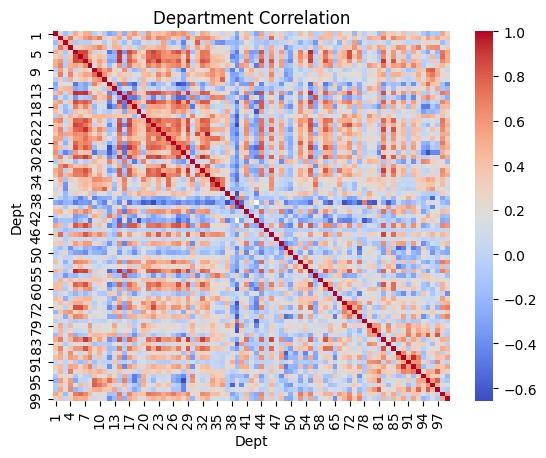

In [29]:
#visualization
sns.heatmap(dept_corr, cmap="coolwarm")
plt.title("Department Correlation")
plt.show()

####I created a heatmap to visualize the correlation between different departments. Red areas indicate strong positive relationships, meaning those departments have similar sales patterns. Blue areas indicate negative relationships. This helps identify departments that can be targeted together for cross-selling strategies.

###cross selling:
Cross-selling strategies were developed by identifying top-performing and highly correlated departments. Related departments can be promoted together through combo offers and strategic placement. This helps in increasing overall sales and improving customer experience.  

Market basket analysis identifies relationships between products to improve cross-selling.

##Demand Forecasting:

In [30]:
#Select Features (X) and Target (y)
features = ["CPI", "Fuel_Price", "Unemployment", "Size", "Total_MarkDown"]

X = data[features].fillna(0)
y = data["Weekly_Sales"]

####I selected relevant features such as CPI, fuel price, unemployment, store size, and markdowns to predict weekly sales.

In [31]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Train model
model = LinearRegression()
model.fit(X_train, y_train)

#Predict Sales
y_pred = model.predict(X_test)

#Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 21982.28324160801


####I built a linear regression model to forecast weekly sales using features such as CPI, fuel price, unemployment, store size, and markdowns. The model was trained and evaluated using RMSE. This approach helps in predicting future demand and supports better inventory and business planning.

####Short-term forecasting focuses on predicting sales for upcoming weeks using recent data, which helps in day-to-day operations. Long-term forecasting analyzes overall trends to support strategic planning such as inventory management and business growth. The regression model can be used for both purposes depending on the time horizon.

##Impact of External Factors:

In [32]:
#Correlation with Sales
corr = data[["Weekly_Sales","CPI","Fuel_Price","Unemployment"]].corr()

print(corr)

              Weekly_Sales       CPI  Fuel_Price  Unemployment
Weekly_Sales      1.000000 -0.020921   -0.000120     -0.025864
CPI              -0.020921  1.000000   -0.164210     -0.299953
Fuel_Price       -0.000120 -0.164210    1.000000     -0.033853
Unemployment     -0.025864 -0.299953   -0.033853      1.000000


####External factors such as CPI, fuel price, and unemployment were analyzed to understand their influence on sales. Correlation analysis showed that these factors have a weak relationship with weekly sales, indicating limited direct impact in this dataset. However, these variables still represent real-world economic conditions that can indirectly affect customer purchasing behavior.

These external factors were incorporated into the demand forecasting model to improve prediction accuracy and ensure that the model captures broader economic influences on sales. Including these variables helps in building a more realistic and robust forecasting model.

##Conclusion:  
This project focused on analyzing retail sales data to optimize store performance and improve demand forecasting. Various data analysis and machine learning techniques were applied, including anomaly detection, time-series analysis, customer segmentation, and demand forecasting.

The analysis revealed important insights such as seasonal trends, higher sales during holidays, and the presence of high-performing and low-performing store segments. Market basket analysis helped identify relationships between departments, enabling effective cross-selling strategies. Demand forecasting using a regression model provided reasonable predictions of future sales, supporting better inventory planning.

Although external factors like CPI, fuel price, and unemployment showed weak direct correlation with sales, they were included in the model to capture real-world economic conditions. Based on these insights, personalized marketing and inventory management strategies were developed to improve overall business performance.

Overall, this project demonstrates how data-driven approaches can help retailers make informed decisions, optimize operations, and enhance customer experience.